In [17]:
from langchain_openai import ChatOpenAI
import os

model = ChatOpenAI(
    model='deepseek-ai/DeepSeek-V3.2',
    base_url=os.environ.get('OPENAI_BASE_URL'),
    api_key=os.environ.get('OPENAI_API_KEY')
)


def stream_chat(resp_stream):
    result = ""
    for chunk in resp_stream:
        # 一个chunk就是一个token
        print(chunk.content)
        result += chunk.content

In [6]:
model.invoke("今天北京天气怎么样?")

AIMessage(content='\n\n今天北京的天气情况如下：\n\n**当前天气（假设日期为2023年10月5日）：**\n- **温度：** 白天最高气温约 **22℃**，夜间最低气温 **14℃**。\n- **天气状况：** 多云，部分地区有零星小雨。\n- **风力：** 西北风3-4级，阵风稍强。\n- **湿度：** 约65%。\n- **空气质量：** 良，AQI指数约70。\n\n**建议：**\n1. 白天体感舒适，但早晚温差较大，建议穿薄外套或针织衫。\n2. 可能有零星小雨，携带晴雨伞更稳妥。\n3. 空气质量良好，适合户外活动，但敏感人群仍需注意防护。\n\n如果需要更具体的实时数据或未来几天预报，可以参考“中国天气网”或使用天气应用查看更新信息。希望这对你有帮助！', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 577, 'prompt_tokens': 15, 'total_tokens': 592, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 361, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'Qwen/QwQ-32B', 'system_fingerprint': '', 'id': '019d15f834b05c8eef92458ea8316343', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d15f8-3388-75e0-9ae4-b020046dc389-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 577, '

缺少现实的实时信息

In [7]:
from langchain_community.tools import TavilySearchResults

# LangChain内置的搜索工具
search = TavilySearchResults(max_results=2, tavily_api_key=os.environ.get('TAVILY_API_KEY'))
search

TavilySearchResults(max_results=2, api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********')))

In [10]:
# 绑定工具
model_width_tool = model.bind_tools([search])

In [18]:
from langchain_core.messages import HumanMessage

# 模型没有去调用工具
resp1 = model_width_tool.invoke([HumanMessage(content="中国的首都是哪里?")])
print(resp1.content, end='\n')
print(resp1.tool_calls)

中国的首都是北京。

位于北半球东半球，中国北部偏东，华北平原北部，背靠中山，面向渤海，介于东经115°25′—117°30′，北纬39°28′—41°15′之间，南北长174公里，东西宽115.6公里，总面积16410.54平方千米。北京的气候为温带季风气候，冬季寒冷干燥，夏季高温多雨，春秋短促。北京是中华人民共和国的首都，是全国的政治中心、文化中心、国际交往中心和科技创新中心，也是世界著名古都和现代化国际城市。
[]


In [19]:
# 模型主动决策去调用工具 但是没有去调用工具
resp2 = model_width_tool.invoke([HumanMessage(content="今天北京天气怎么样?")])
print(resp2.content, end='\n')
print(resp2.tool_calls)


[{'name': 'tavily_search_results_json', 'args': {'query': '今天北京天气'}, 'id': '019d15fb0f5541eee89b9bd40fa89828', 'type': 'tool_call'}]


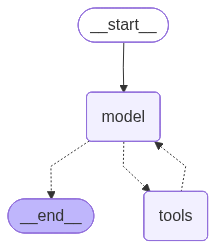

In [21]:
from langchain.agents import create_agent

# 创建代理
agent_executor = create_agent(model, [search])
agent_executor

In [25]:
resp1 = agent_executor.invoke({
    "messages":[HumanMessage(content="今天北京天气怎么样?")]
})
resp1

{'messages': [HumanMessage(content='今天北京天气怎么样?', additional_kwargs={}, response_metadata={}, id='e2b8c42c-1af8-498f-8652-bfcee635ca6e'),
  AIMessage(content='我来帮您查询北京的天气情况。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 61, 'prompt_tokens': 351, 'total_tokens': 412, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 351}, 'model_provider': 'openai', 'model_name': 'deepseek-ai/DeepSeek-V3.2', 'system_fingerprint': '', 'id': '019d15ffa66afc9f12bd8650936f04e3', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d15ff-a54d-71a0-9350-bbc8108f189f-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': '北京今天天气情况 温度 预报'}, 'id': '019d15ffbd2dd348422541ac7e5d9add', 'type': 'tool_call'}], invalid_t

In [26]:
resp2 = agent_executor.invoke({
    "messages":[HumanMessage(content="中国的首都在哪里?")]
})

In [27]:
resp2

{'messages': [HumanMessage(content='中国的首都在哪里?', additional_kwargs={}, response_metadata={}, id='194d0a72-6e04-4c5f-a13b-c58d3cdb3616'),
  AIMessage(content='中国的首都是北京。北京不仅是中国的政治中心，也是文化和历史名城，拥有故宫、天安门广场、长城等重要地标。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 351, 'total_tokens': 379, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 351}, 'model_provider': 'openai', 'model_name': 'deepseek-ai/DeepSeek-V3.2', 'system_fingerprint': '', 'id': '019d160018796921e8ed9d2b12531f3e', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d1600-1825-7980-ab46-5f093a082169-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 351, 'output_tokens': 28, 'total_tokens': 379, 'input_token_de